In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target # 0 = Benigno, 1 = Maligno
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

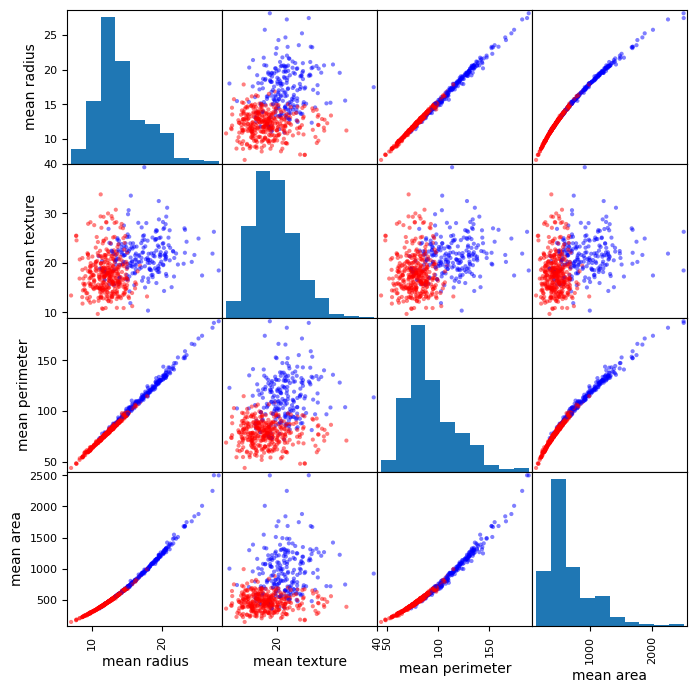

In [3]:
# from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df.iloc[:, :4], c=df['target'], cmap='bwr', figsize=(8,8))
plt.show()

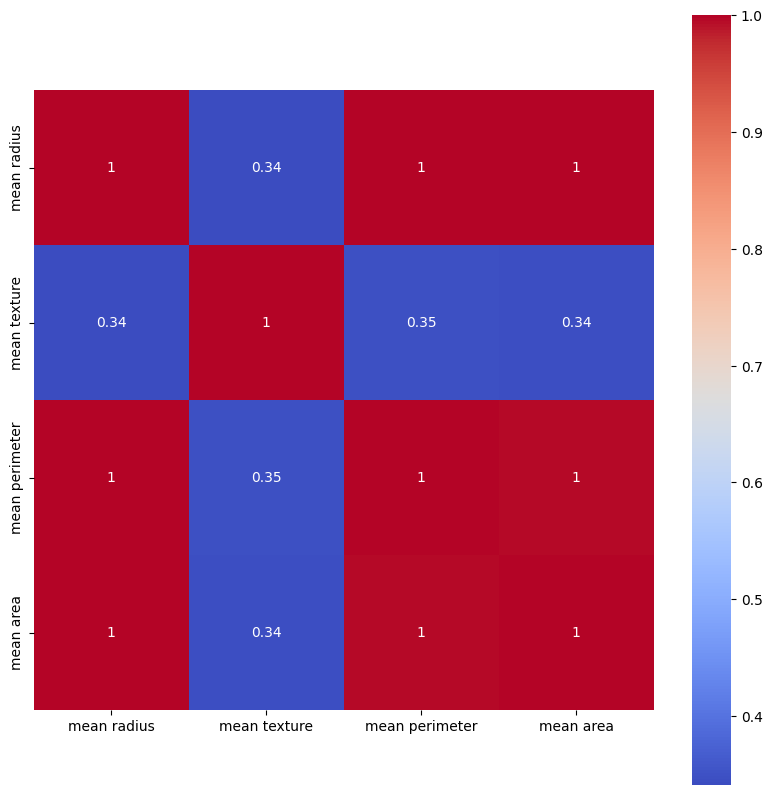

In [4]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(df.iloc[:, 0:4].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.show()

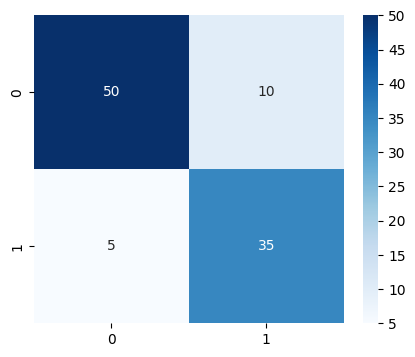

In [5]:
cm = [[50, 10], [5, 35]]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

#### Sección 3.4

Seleccionar __tres__ variables del conjunto con diferente correlación con el diagnóstico: una de alta correlación, una de correlación media y una de baja correlación. Para ello calcula la matriz de correlación y ordena los valores en orden descendente. Puedes usar `df.corr()[['target']]` par obtener la correlación de todas las variables con el diagnóstico (target).

En `df_correlacion` guardamos el DataFrame sin considerar el primer elemento `[1:]`, pues dicho elemento corresponde a la correlación de _target_ con _target_. 

In [29]:
df_correlacion = df.corr()[['target']].sort_values(by='target', key=lambda x: abs(x), ascending=False)[:]

# maxima = df_correlacion.iloc[0]

# mitad = df_correlacion.iloc[10]

# minima = df_correlacion.iloc[-1]

# minima, mitad, maxima

df_correlacion

,target
target,1.000000
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360


Estudia las tres variables, puedes usar `df['VARIABLE'].describe()` para analizar su distribución y valores estadísticos.

Dibuja las variables para tumores malignos y benignos, y usa la estimaci ́on de densidad de kernel (KDE) para visualizar su distribuci ́on.

In [31]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


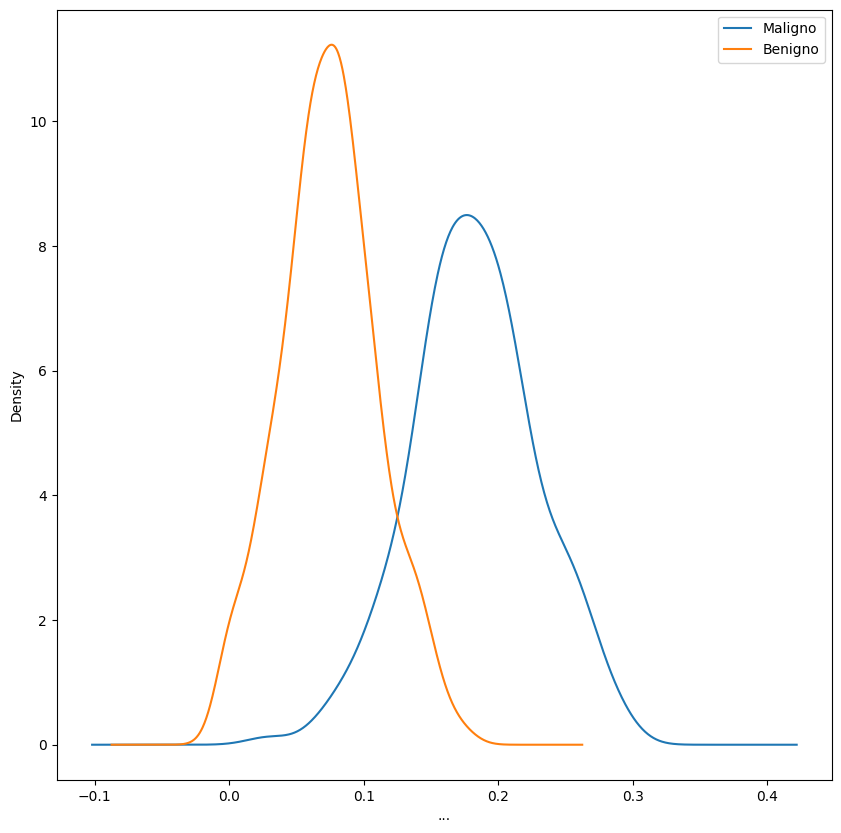

In [39]:
df.groupby("target")["worst concave points"].plot(kind='kde', figsize=(10, 10))
plt.legend(['Maligno', 'Benigno'], loc='upper right')
plt.xlabel('...')
plt.show()

In [37]:
df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


`DataFrame.astype(int)` para convertir booleano a entero:
* `int(False) -> 0`
* `int(True) -> 1`  

In [52]:
umbral = 0.12

df['prediccion'] = (df['worst concave points'] < umbral).astype(int)  # 0: benigno, 1:maligno

In [64]:
FP = df[(df['target']==0) & (df['prediccion']==1)]

FN = df[(df['target']==1) & (df['prediccion']==0)]

In [69]:
print(FP[['worst concave points', 'target', 'prediccion']])

FP.shape[0]

     worst concave points  target  prediccion
10                0.09975       0           1
13                0.11190       0           1
38                0.02899       0           1
40                0.11120       0           1
100               0.11840       0           1
119               0.11850       0           1
135               0.09331       0           1
171               0.11600       0           1
197               0.09181       0           1
207               0.10960       0           1
213               0.10990       0           1
261               0.08235       0           1
263               0.08568       0           1
274               0.11360       0           1
297               0.07160       0           1
329               0.10470       0           1
414               0.06575       0           1
489               0.08737       0           1
514               0.11200       0           1


19

Ejercicio 11 son 3 gráficas